<a href="https://colab.research.google.com/github/shouib09/Machine-Learning-Lab/blob/main/irisflower_classification_exp_12.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Accuracy: 0.9778


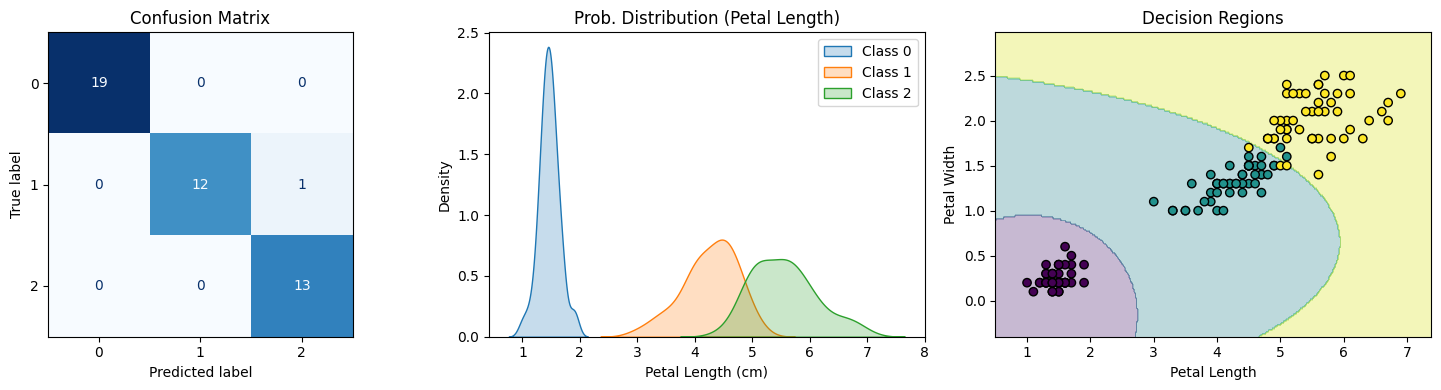

In [1]:

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay

# 1. Load Data & Train Model
X, y = load_iris(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
gnb = GaussianNB().fit(X_train, y_train)

# 2. Evaluate
y_pred = gnb.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")

# 3. Visualizations (1x3 Subplots)
fig, ax = plt.subplots(1, 3, figsize=(15, 4))

# A. Confusion Matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax[0], cmap='Blues', colorbar=False)
ax[0].set_title("Confusion Matrix")

# B. Probability Distribution (Using Petal Length - Feature Index 2)
for i in range(3):
    sns.kdeplot(X[y == i, 2], ax=ax[1], fill=True, label=f'Class {i}')
ax[1].set(title="Prob. Distribution (Petal Length)", xlabel="Petal Length (cm)")
ax[1].legend()

# C. Decision Regions (Using Petal Length & Width - Features 2 & 3)
X_2d = X[:, 2:4]
gnb_2d = GaussianNB().fit(X_train[:, 2:4], y_train) # Retrain on just 2 features for 2D plotting
x_min, x_max = X_2d[:, 0].min() - 0.5, X_2d[:, 0].max() + 0.5
y_min, y_max = X_2d[:, 1].min() - 0.5, X_2d[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02), np.arange(y_min, y_max, 0.02))
Z = gnb_2d.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

ax[2].contourf(xx, yy, Z, alpha=0.3, cmap='viridis')
ax[2].scatter(X_2d[:, 0], X_2d[:, 1], c=y, edgecolor='k', cmap='viridis')
ax[2].set(title="Decision Regions", xlabel="Petal Length", ylabel="Petal Width")

plt.tight_layout()
plt.show()